In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_bin'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [6]:
num = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
cat = pd.get_dummies(df[['Contract', 'PaymentMethod']], drop_first=True)
X = pd.concat([num, cat], axis=1)
y = df['Churn_bin']
print(X.shape)
print(X.columns)

(7043, 9)
Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [7]:
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X, y, random_state=42)
mi_score = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_score.round(4)

,0
tenure,0.0772
Contract_Two year,0.0546
MonthlyCharges,0.0432
TotalCharges,0.0431
PaymentMethod_Electronic check,0.0369
PaymentMethod_Credit card (automatic),0.0169
SeniorCitizen,0.0138
Contract_One year,0.0116
PaymentMethod_Mailed check,0.0008


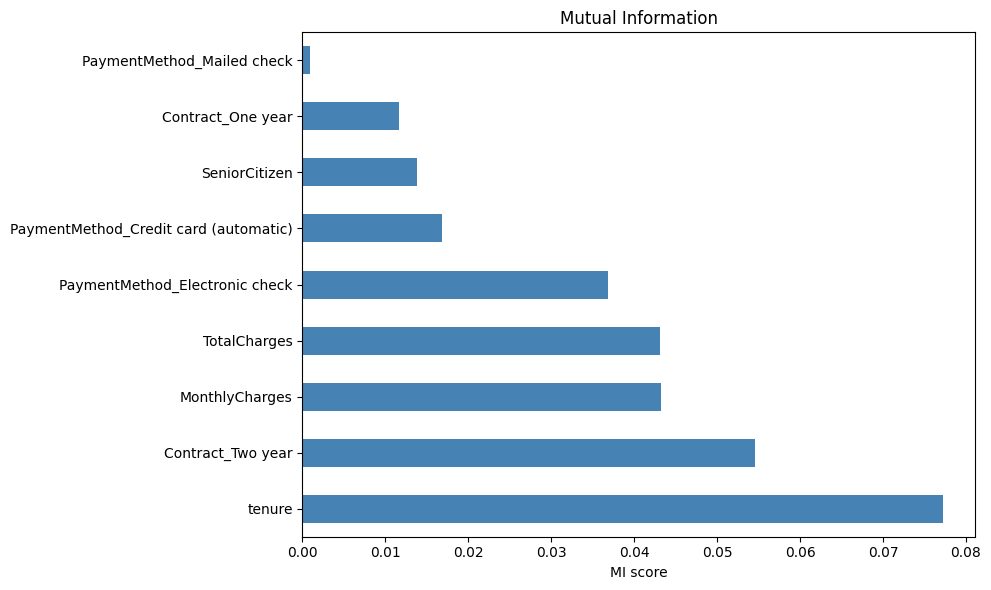

In [8]:
plt.figure(figsize=(10, 6))
mi_score.plot(kind='barh', color='steelblue')
plt.title('Mutual Information')
plt.xlabel('MI score')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=3)
rfe.fit(X_scaled, y)
result = pd.DataFrame({'Features': X.columns, 'Kept': rfe.support_ , 'Rank': rfe.ranking_})
result.sort_values('Rank')

,Features,Kept,Rank
0,tenure,True,1
1,MonthlyCharges,True,1
5,Contract_Two year,True,1
2,TotalCharges,False,2
4,Contract_One year,False,3
7,PaymentMethod_Electronic check,False,4
3,SeniorCitizen,False,5
8,PaymentMethod_Mailed check,False,6
6,PaymentMethod_Credit card (automatic),False,7


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
m_all = LogisticRegression(max_iter=1000).fit(X_train, y_train)
print(f"All features: {round(accuracy_score(y_test, m_all.predict(X_test)), 4)}")

idx = np.where(rfe.support_)[0]
m_top = LogisticRegression(max_iter=1000).fit(X_train[:,idx], y_train)
print(f"Top features: {round(accuracy_score(y_test, m_top.predict(X_test[:, idx])), 4)}")

All features: 0.802
Top features: 0.8006
